# 01 · Separación BCG/ICL y Fracción de Masa del ICL
**Metodología:** §2.2 y §3 de Mayes+2026

1. **Rotación por tensor de inercia reducido** — usando la misma construcción que `Catalogue.comp_Reduced_Inertia_tensor()`
2. **Perfil de brillo superficial 1D** en banda r a lo largo del eje semi-mayor
3. **Radio de Holmberg** — corte en μ_r = 26.5 mag/arcsec² (separación BCG/ICL)
4. **Fracción de masa del ICL** vs masa, concentración y tiempo del último merger

**Equivalente a:** Figs. 1, 2, 3, 4, 5 de Mayes+2026


In [35]:
import sys, os, pickle
import numpy as np
import h5py
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.optimize import curve_fit
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

# ── Importar código del proyecto (solo lectura) ──────────────────────────
sys.path.insert(0, './original_shift_code')
import illustris_python as il
import Catalogue                 # para Distance_3D, CM_3D, etc.
import params_icl as P

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 
                     'font.size': 12,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089)


## Cargar catálogo

In [36]:
with h5py.File(P.CATALOG_OUT, 'r') as f:
    group_idx     = f['group_idx'][:]
    M200c         = f['M200c_Msun'][:]
    R200c         = f['R200c_kpc'][:]
    GroupPos      = f['GroupPos_kpc'][:]
    bcg_sub_idx   = f['bcg_sub_idx'][:]
    t_last_merger = f['t_last_merger_Gyr'][:]
    # Estado dinámico (si ya fue añadido)
    dyn_state = f['dyn_state'][:] if 'dyn_state' in f else None

n_cl = len(group_idx)
Header = il.groupcat.loadHeader(P.basePath, P.SNAP)

print(f"Catálogo cargado: {n_cl} cúmulos")
print(f"Estado dinámico disponible: {dyn_state is not None}")

# Colores por estado dinámico
COLORS_STATE  = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}
LABELS_STATE  = {0: 'Relajado', 1: 'Intermedio', 2: 'Perturbado'}
COLORS_COMP   = {0: '#E91E63', 1: '#9C27B0', 2: '#00BCD4'}
LABELS_COMP   = {0: 'In situ', 1: 'Mergers', 2: 'Stripped'}


Catálogo cargado: 53 cúmulos
Estado dinámico disponible: False


## §2.2 – Rotación por tensor de inercia

Usamos la misma construcción que `Catalogue.comp_Reduced_Inertia_tensor()` pero pedimos eigenvectores para rotar las partículas.

In [37]:
def rotate_by_inertia_tensor(pos_rel, mass, r_lim=np.inf):
    """
    Alinea las partículas con los ejes principales del tensor de inercia reducido.
    Usa la misma construcción que Catalogue.comp_Reduced_Inertia_tensor().

    pos_rel : (N,3) posiciones relativas al BCG [kpc]
    mass    : (N,)  masas de las partículas
    r_lim   : float, radio límite para el cálculo del tensor [kpc]

    Devuelve
    --------
    pos_rot : (N,3) posiciones rotadas (eje mayor → x̂, menor → ẑ)
    R_mat   : (3,3) matriz de rotación
    """
    dist = np.linalg.norm(pos_rel, axis=1)
    ok   = (dist > 0) & (dist <= r_lim) & np.isfinite(mass)
    p, m = pos_rel[ok], mass[ok]

    if m.sum() == 0 or len(m) < 4:
        return pos_rel, np.eye(3)

    # Tensor de inercia reducido (ponderado por 1/r²)
    w    = 1.0 / dist[ok]**2
    mtot = np.sum(m)
    Ixx  = np.sum(m * p[:,0]**2 * w) / mtot
    Iyy  = np.sum(m * p[:,1]**2 * w) / mtot
    Izz  = np.sum(m * p[:,2]**2 * w) / mtot
    Ixy  = np.sum(m * p[:,0] * p[:,1] * w) / mtot
    Ixz  = np.sum(m * p[:,0] * p[:,2] * w) / mtot
    Iyz  = np.sum(m * p[:,1] * p[:,2] * w) / mtot
    I = np.array([[Ixx, Ixy, Ixz],
                  [Ixy, Iyy, Iyz],
                  [Ixz, Iyz, Izz]])

    eigvals, eigvecs = np.linalg.eigh(I)
    # eigh devuelve valores en orden ascendente
    # eigenvalor mayor → eje de mayor extensión (semi-eje mayor) → queremos que sea x̂
    idx   = np.argsort(eigvals)[::-1]   # descendente: mayor primero
    R_mat = eigvecs[:, idx].T           # filas = ejes principales
    pos_rot = pos_rel @ R_mat.T
    return pos_rot, R_mat


## §2.2 – Perfil de brillo superficial en banda r y radio de Holmberg

In [38]:
def sb_profile_r(r_2d, lum_r, r_max_kpc, n_bins=60):
    """
    Perfil 1D de brillo superficial en banda r.

    r_2d    : distancias 2D proyectadas [kpc]
    lum_r   : luminosidad r de cada partícula [L☉]
                GFM_StellarPhotometrics[:, 5] = magnitud abs r-band (AB)
                L = 10^((M_sun,r - mag) / 2.5)
    r_max_kpc: radio máximo [kpc]

    Conversión:
        μ_r [mag/arcsec²] = M_☉,r + 21.572 − 2.5 log₁₀(Σ_L [L☉/pc²])
    """
    r_bins = np.logspace(np.log10(0.5), np.log10(r_max_kpc), n_bins + 1)
    r_mid  = np.sqrt(r_bins[:-1] * r_bins[1:])   # media geométrica
    mu_r   = np.full(n_bins, np.nan)

    for k, (r1, r2) in enumerate(zip(r_bins[:-1], r_bins[1:])):
        mk = (r_2d >= r1) & (r_2d < r2)
        if mk.sum() == 0:
            continue
        area_pc2 = np.pi * ((r2 * 1e3)**2 - (r1 * 1e3)**2)   # kpc→pc, anillo
        sigma_L  = lum_r[mk].sum() / area_pc2
        if sigma_L > 0:
            mu_r[k] = P.SB_CONST - 2.5 * np.log10(sigma_L)

    return r_mid, mu_r


def holmberg_radius(r_mid, mu_r, mu_cut=P.MU_HOLMBERG):
    """Interpola el radio donde μ_r = mu_cut."""
    valid = np.isfinite(mu_r) & (r_mid > 0)
    if valid.sum() < 3:
        return np.nan
    # μ crece con r; necesitamos que sea monótonamente creciente para invertir
    r_v, m_v = r_mid[valid], mu_r[valid]
    # Ordenar por radio por si hay ruido
    idx_s = np.argsort(r_v)
    r_v, m_v = r_v[idx_s], m_v[idx_s]
    if m_v[0] > mu_cut or m_v[-1] < mu_cut:
        return np.nan
    try:
        f = interp1d(m_v, r_v, kind='linear', fill_value='extrapolate')
        r_h = float(f(mu_cut))
        return r_h if 0 < r_h <= r_v[-1] * 1.2 else np.nan
    except Exception:
        return np.nan


In [39]:
group_idx

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52])

## §2.2 – Separación BCG/ICL: demostración con un cúmulo

In [40]:
# Elegir el cúmulo más masivo como ejemplo
i_demo = 8
sub_id = int(bcg_sub_idx[i_demo])
cen    = GroupPos[i_demo]   # kpc físicos

print(f"Cúmulo demo: group_idx={group_idx[i_demo]}, "
      f"sub_id={sub_id}, log M200c={np.log10(M200c[i_demo]):.2f}")

Cúmulo demo: group_idx=8, sub_id=83280, log M200c=14.32


In [41]:
# Cargar partículas estelares del subhalo central (BCG+ICL)
# Todas las estrellas no ligadas a satélites están en el subhalo central
fields = ['Coordinates', 'Masses', 'GFM_StellarPhotometrics',
          'GFM_Metallicity', 'GFM_StellarFormationTime']
stars = il.snapshot.loadSubhalo(P.basePath, P.SNAP, sub_id, 'stars', fields=fields)

# Convertir unidades
pos   = stars['Coordinates'] * P.UL               # kpc físicos
mass  = stars['Masses'] * P.UM                    # M☉
phot  = stars['GFM_StellarPhotometrics']           # mag abs AB (U,B,V,K,g,r,i,z)
metal = stars['GFM_Metallicity']                   # fracción metálica Z
aform = stars['GFM_StellarFormationTime']          # factor de escala de formación

print(f"N partículas estelares: {len(mass):,}")

# Centrar respecto al BCG usando Distance_3D (corrige periodicidad)
pos_c = Catalogue.Distance_3D(pos, cen, Header['BoxSize'] * P.UL)

# Rotar al plano del eje mayor (face-on)
pos_rot, R_mat = rotate_by_inertia_tensor(pos_c, mass)

# Proyección 2D (plano xy)
r_2d = np.sqrt(pos_rot[:, 0]**2 + pos_rot[:, 1]**2)

# Luminosidad r-band: índice 5 en GFM_StellarPhotometrics (U,B,V,K,g,r,i,z)
lum_r = 10**((P.M_SUN_R_AB - phot[:, 5]) / 2.5)   # L☉

# Perfil de brillo superficial
r_max = np.percentile(r_2d, 99)
r_mid, mu_r = sb_profile_r(r_2d, lum_r, r_max)

# Radio de Holmberg
r_h = holmberg_radius(r_mid, mu_r)
print(f"Radio de Holmberg: {r_h:.1f} kpc")

# Separación BCG/ICL
mask_bcg = r_2d <= r_h
mask_icl = r_2d >  r_h
M_bcg_demo = mass[mask_bcg].sum()
M_icl_demo = mass[mask_icl].sum()
print(f"f_ICL = {M_icl_demo/(M_bcg_demo+M_icl_demo):.3f}")


N partículas estelares: 2,226,171
Radio de Holmberg: 167.9 kpc
f_ICL = 0.245


### Figura 1 – Perfil de brillo superficial 1D (= Fig. 1 del paper)

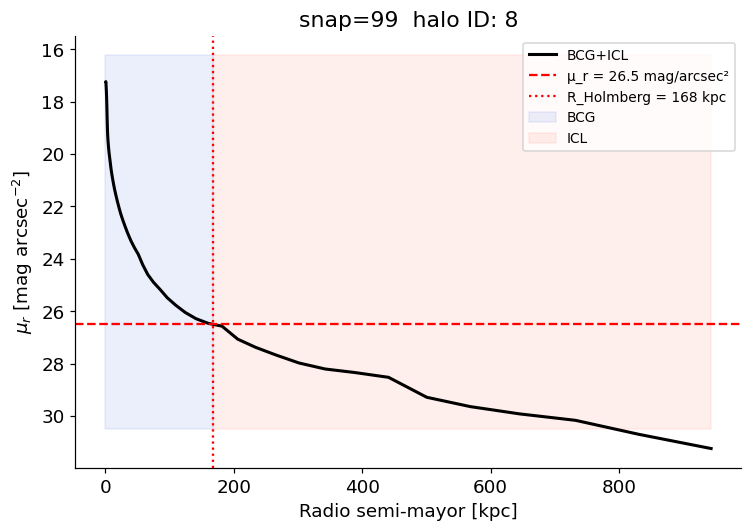

In [42]:
fig, ax = plt.subplots(figsize=(7, 5))
valid = np.isfinite(mu_r)

ax.plot(r_mid[valid], mu_r[valid], 'k-', lw=2, label='BCG+ICL')
ax.axhline(P.MU_HOLMBERG, color='r', ls='--', lw=1.5,
           label=f'μ_r = {P.MU_HOLMBERG} mag/arcsec²')
if np.isfinite(r_h):
    ax.axvline(r_h, color='r', ls=':', lw=1.5,
               label=f'R_Holmberg = {r_h:.0f} kpc')
    ax.fill_betweenx([mu_r[valid].min()-1, P.MU_HOLMBERG+4],
                      0, r_h, alpha=0.10, color='royalblue', label='BCG')
    ax.fill_betweenx([mu_r[valid].min()-1, P.MU_HOLMBERG+4],
                      r_h, r_mid[valid][-1], alpha=0.10, color='tomato', label='ICL')

#ax.set_xscale('log')
ax.invert_yaxis()
ax.set_xlabel('Radio semi-mayor [kpc]')
ax.set_ylabel(r'$\mu_r$ [mag arcsec$^{-2}$]')
ax.set_title(f'snap={P.SNAP}  halo ID: {group_idx[i_demo]}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig01_perfil_sb.pdf', bbox_inches='tight')
plt.show()

### Figura 2 – Mapa 2D de brillo superficial (= Fig. 2 del paper)

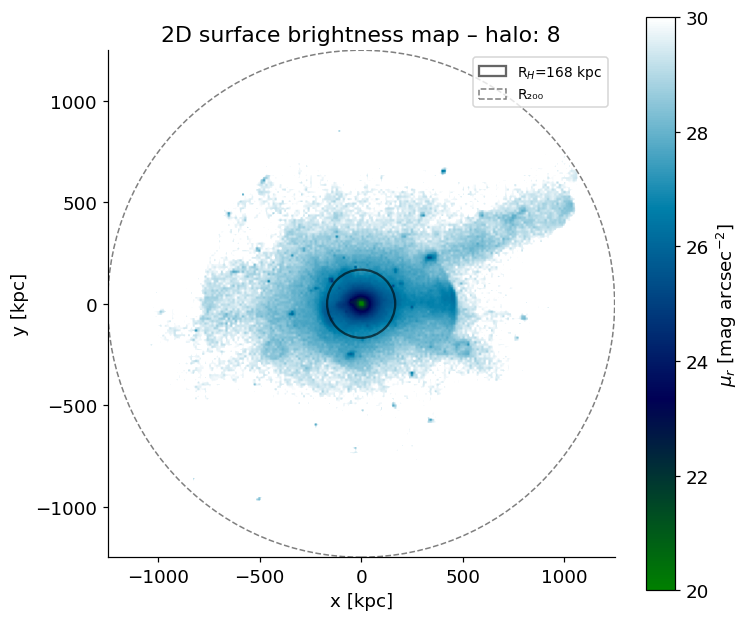

In [43]:
from scipy.stats import binned_statistic_2d

r_plot  = R200c[i_demo]
n_pix   = 216
edges   = np.linspace(-r_plot, r_plot, n_pix + 1)
pix_pc2 = ((2 * r_plot / n_pix) * 1e3)**2

H, _, _, _ = binned_statistic_2d(pos_rot[:, 0], pos_rot[:, 1],
                                   lum_r, statistic='sum',
                                   bins=[edges, edges])

with np.errstate(divide='ignore', invalid='ignore'):
    sigma = np.where(H > 0, H / pix_pc2, np.nan)
    mu_map = np.where(sigma > 0, P.SB_CONST - 2.5 * np.log10(sigma), np.nan)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mu_map.T, origin='lower', cmap='ocean',
               extent=[-r_plot, r_plot, -r_plot, r_plot],
               vmin=20, vmax=30)

plt.colorbar(im, ax=ax, label=r'$\mu_r$ [mag arcsec$^{-2}$]')

if np.isfinite(r_h):
    ax.add_patch(plt.Circle((0, 0), r_h,   fill=False, color='black',
                              lw=1.5, label=f'R$_H$={r_h:.0f} kpc', alpha=0.6))
    
ax.add_patch(plt.Circle((0, 0), r_plot, fill=False, color='gray',
                          lw=1, ls='--', label='R₂₀₀'))
ax.set_xlabel('x [kpc]'); ax.set_ylabel('y [kpc]')
ax.set_title(f'2D surface brightness map – halo: {group_idx[i_demo]}')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('fig02_mapa_sb.pdf', bbox_inches='tight')
plt.show()


## §3 – Fracción de masa ICL para todos los cúmulos

In [44]:
def bcg_icl_mass_fraction(sub_id, cen_pos, header=Header):
    """
    Carga partículas del subhalo central, aplica el corte de Holmberg
    y devuelve (f_ICL, M_BCG, M_ICL) en M☉.
    """
    try:
        fields = ['Coordinates', 'Masses', 'GFM_StellarPhotometrics']
        st = il.snapshot.loadSubhalo(P.basePath, P.SNAP, int(sub_id), 'stars', fields=fields)
        pos  = Catalogue.Distance_3D(st['Coordinates'] * P.UL, cen_pos, header['BoxSize'] * P.UL)
        mass = st['Masses'] * P.UM
        lum  = 10**((P.M_SUN_R_AB - st['GFM_StellarPhotometrics'][:, 5]) / 2.5)
        pos_rot, _ = rotate_by_inertia_tensor(pos, mass)
        r2   = np.sqrt(pos_rot[:,0]**2 + pos_rot[:,1]**2)
        r_m, mu = sb_profile_r(r2, lum, np.percentile(r2, 99))
        r_h  = holmberg_radius(r_m, mu)
        if not np.isfinite(r_h): return np.nan, np.nan, np.nan
        m_bcg = mass[r2 <= r_h].sum()
        m_icl = mass[r2 >  r_h].sum()
        m_tot = m_bcg + m_icl
        return (m_icl / m_tot, m_bcg, m_icl) if m_tot > 0 else (np.nan, np.nan, np.nan)
    except Exception as e:
        return np.nan, np.nan, np.nan

icl_frac = np.full(n_cl, np.nan)
M_bcg    = np.full(n_cl, np.nan)
M_icl    = np.full(n_cl, np.nan)

print("Calculando fracciones de masa ICL...")
for i in range(n_cl):
    icl_frac[i], M_bcg[i], M_icl[i] = bcg_icl_mass_fraction(
        bcg_sub_idx[i], GroupPos[i])
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{n_cl}  f_ICL_med={np.nanmedian(icl_frac[:i+1]):.3f}", end="\r")

# Guardar en el catálogo
with h5py.File(P.CATALOG_OUT, 'a') as f:
    for k, v in [('icl_frac', icl_frac), ('M_bcg_Msun', M_bcg), ('M_icl_Msun', M_icl)]:
        if k in f: del f[k]
        f.create_dataset(k, data=v)
print(f"\nf_ICL = {np.nanmean(icl_frac):.3f} ± {np.nanstd(icl_frac):.3f}")


Calculando fracciones de masa ICL...
  50/53  f_ICL_med=0.204
f_ICL = 0.211 ± 0.061


### Figura 3 – Fracción de masa ICL vs M₂₀₀ (= Fig. 3 del paper)

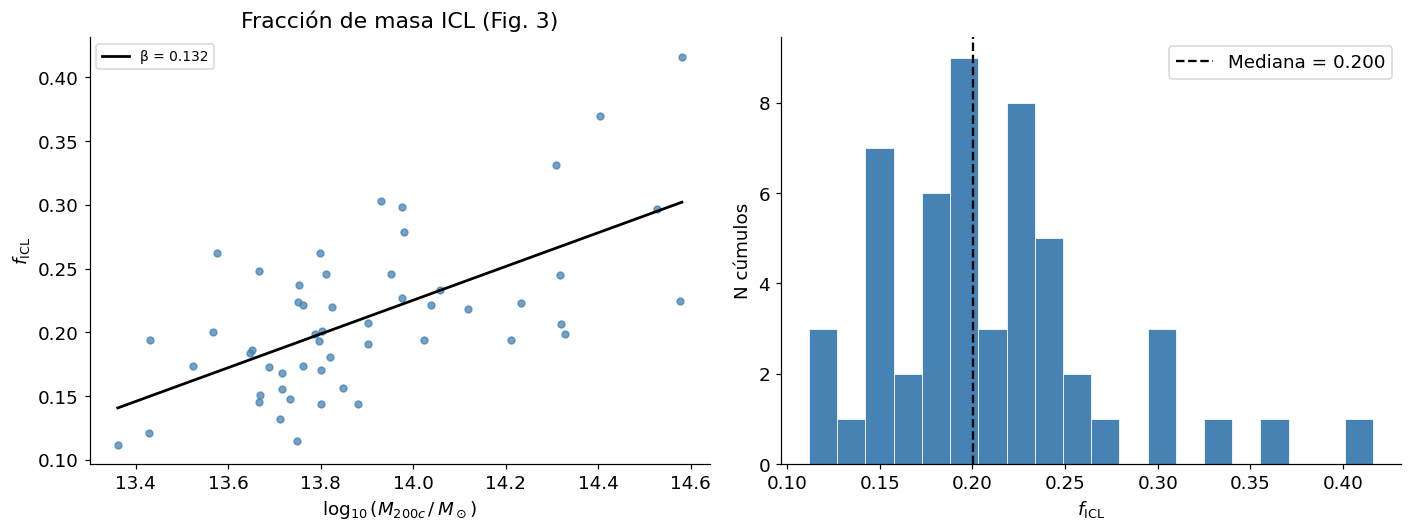

In [45]:
def linfit(x, y, log_x=True):
    xx = np.log10(x) if log_x else np.asarray(x)
    yy = np.asarray(y)
    ok = np.isfinite(xx) & np.isfinite(yy)
    sl, ic, *_ = linregress(xx[ok], yy[ok])
    return sl, ic, xx[ok], yy[ok]

lM = np.log10(M200c)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
if dyn_state is not None:
    for s in [0, 1, 2]:
        m = dyn_state == s
        ax.scatter(lM[m], icl_frac[m], color=COLORS_STATE[s],
                   label=LABELS_STATE[s], s=20, alpha=0.75)
else:
    ax.scatter(lM, icl_frac, color='steelblue', s=20, alpha=0.75)

sl, ic, lx, ly = linfit(M200c, icl_frac)
xx = np.linspace(lx.min(), lx.max(), 100)
ax.plot(xx, sl*xx+ic, 'k-', lw=1.8, label=f'β = {sl:.3f}')
ax.set_xlabel(r'$\log_{10}(M_{200c}\,/\,M_\odot)$')
ax.set_ylabel(r'$f_{\rm ICL}$')
ax.set_title('Fracción de masa ICL (Fig. 3)')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(icl_frac[np.isfinite(icl_frac)], bins=20,
        color='steelblue', edgecolor='white', lw=0.5)
ax.axvline(np.nanmedian(icl_frac), ls='--', color='k', lw=1.5,
           label=f'Mediana = {np.nanmedian(icl_frac):.3f}')
ax.set_xlabel(r'$f_{\rm ICL}$')
ax.set_ylabel('N cúmulos')
ax.legend()

plt.tight_layout()
plt.savefig('fig03_icl_vs_masa.pdf', bbox_inches='tight')
plt.show()


### Figura 4 – Fracción ICL vs concentración NFW (= Fig. 4 del paper)

Calculamos c₂₀₀ ajustando un perfil NFW al perfil de masa encerrada de la materia oscura.

Calculando concentración NFW para cada cúmulo...


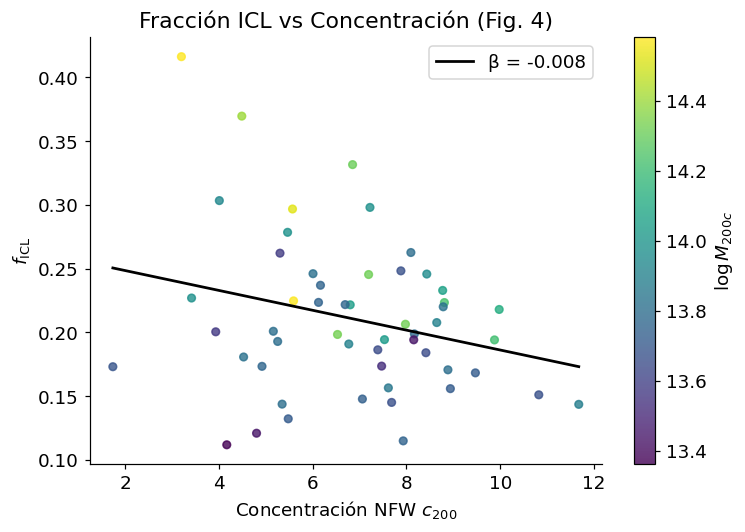

In [46]:
def nfw_enclosed_norm(r, r_s):
    """Masa encerrada NFW normalizada a r200."""
    x200 = R200c[_i_nfw] / r_s
    x    = r / r_s
    return (np.log(1 + x) - x/(1+x)) / (np.log(1+x200) - x200/(1+x200))

def compute_concentration(sub_id_or_halo_idx, r200, cen_pos, header=Header):
    """Ajusta perfil NFW a las partículas DM del halo."""
    try:
        dm = il.snapshot.loadHalo(P.basePath, P.SNAP, int(sub_id_or_halo_idx),
                                   'dm', fields=['Coordinates'])
        if not isinstance(dm, np.ndarray): dm = dm
        pos_dm = Catalogue.Distance_3D(dm * P.UL, cen_pos, header['BoxSize'] * P.UL)
        r_dm   = np.linalg.norm(pos_dm, axis=1)
        r_bins = np.logspace(np.log10(1.0), np.log10(r200), 31)
        r_mid  = np.sqrt(r_bins[:-1] * r_bins[1:])
        M_enc  = np.array([(r_dm < rb).sum() for rb in r_bins[1:]], dtype=float)
        if M_enc[-1] == 0: return np.nan
        M_enc /= M_enc[-1]
        popt, _ = curve_fit(lambda r, rs: (np.log(1+r/rs) - (r/rs)/(1+r/rs)) /
                                           (np.log(1+r200/rs) - (r200/rs)/(1+r200/rs)),
                             r_mid, M_enc, p0=[r200/5], bounds=(0.1, r200))
        return r200 / popt[0]
    except Exception:
        return np.nan

print("Calculando concentración NFW para cada cúmulo...")
concentration = np.full(n_cl, np.nan)
for i in range(n_cl):
    _i_nfw = i
    concentration[i] = compute_concentration(group_idx[i], R200c[i], GroupPos[i])
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{n_cl}  c_med={np.nanmedian(concentration[:i+1]):.2f}", end="\r")

# Guardar en catálogo
with h5py.File(P.CATALOG_OUT, 'a') as f:
    if 'concentration' in f: del f['concentration']
    f.create_dataset('concentration', data=concentration)

fig, ax = plt.subplots(figsize=(7, 5))
valid = np.isfinite(concentration) & np.isfinite(icl_frac)
sc = ax.scatter(concentration[valid], icl_frac[valid],
                c=lM[valid], cmap='viridis', s=25, alpha=0.8)
plt.colorbar(sc, ax=ax, label=r'$\log M_{200c}$')
sl, ic, cx, cy = linfit(concentration[valid], icl_frac[valid], log_x=False)
xx = np.linspace(cx.min(), cx.max(), 100)
ax.plot(xx, sl*xx+ic, 'k-', lw=1.8, label=f'β = {sl:.3f}')
ax.set_xlabel('Concentración NFW $c_{200}$')
ax.set_ylabel(r'$f_{\rm ICL}$')
ax.set_title('Fracción ICL vs Concentración (Fig. 4)')
ax.legend()
plt.tight_layout()
plt.savefig('fig04_icl_vs_concentracion.pdf', bbox_inches='tight')
plt.show()


### Figura 5 – Fracción ICL vs tiempo desde el último merger mayor (= Fig. 5)

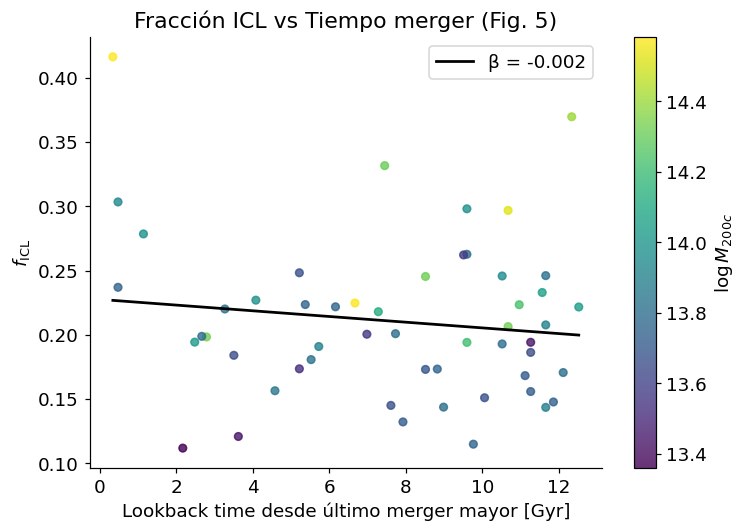

β = -0.002  (positivo → más tiempo desde merger = mayor f_ICL ✓)


In [47]:
fig, ax = plt.subplots(figsize=(7, 5))
valid = np.isfinite(t_last_merger) & np.isfinite(icl_frac)
sc = ax.scatter(t_last_merger[valid], icl_frac[valid],
                c=lM[valid], cmap='viridis', s=25, alpha=0.8)
plt.colorbar(sc, ax=ax, label=r'$\log M_{200c}$')
sl, ic, tx, ty = linfit(t_last_merger[valid], icl_frac[valid], log_x=False)
xx = np.linspace(tx.min(), tx.max(), 100)
ax.plot(xx, sl*xx+ic, 'k-', lw=1.8, label=f'β = {sl:.3f}')
ax.set_xlabel('Lookback time desde último merger mayor [Gyr]')
ax.set_ylabel(r'$f_{\rm ICL}$')
ax.set_title('Fracción ICL vs Tiempo merger (Fig. 5)')
ax.legend()
plt.tight_layout()
plt.savefig('fig05_icl_vs_merger.pdf', bbox_inches='tight')
plt.show()
print(f"β = {sl:.3f}  (positivo → más tiempo desde merger = mayor f_ICL ✓)")
